#  Calculation of features from available libraries

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
dataset = 'Fe-Mo'# 'Fe-Mo'  # 'Cr-Co-W' # 
components = dataset.split('-')
system=dataset.replace('-','')
from  dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer

import Tools.DatasetTools.GeneralFeaturizer as gf

BS = pd.read_pickle(os.path.join(dataset, 'FullyCuratedParsedBriefSummary.pkl'))

In [3]:
BS.describe()

,E0,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
count,292.000000,292.000000,292.000000,292.000000,292.00000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000
mean,-9.347206,1.845890,235.138358,13.582107,12.89726,10.291096,23.188356,0.498634,0.501366,0.250462,0.229052,0.205263
std,0.746336,0.361674,31.685307,1.654945,10.85723,9.537817,13.755429,0.292605,0.292605,0.161952,0.162156,0.166363
min,-10.932821,1.000000,141.243922,10.193528,1.00000,0.000000,1.000000,0.000000,0.000000,-0.015446,-0.042841,-0.085488
25%,-9.955671,2.000000,217.823336,12.275667,4.00000,2.750000,13.000000,0.262500,0.266667,0.124923,0.102939,0.072821
50%,-9.332258,2.000000,240.028922,13.425116,10.00000,8.500000,24.000000,0.500000,0.500000,0.228259,0.196050,0.176500
75%,-8.825165,2.000000,260.406947,14.978348,18.00000,16.000000,30.000000,0.733333,0.737500,0.364194,0.336165,0.309251
max,-7.780036,2.000000,287.828951,16.550514,53.00000,52.000000,53.000000,1.000000,1.000000,0.720532,0.720492,0.720492


In [4]:
AtomsObjects = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{dataset}-POSCAR-initial-rescaled-AtomsObjects.pkl')).dropna()

PymatgenStructures = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{dataset}-POSCAR-initial-rescaled-PymatgenStructures.pkl')).dropna()
SublatticeTags = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SUBLATICETAGS.pkl'))
SublatticeSorters = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SORTERS.pkl'))
SublatticeSorters.index = SublatticeSorters.index.str.strip()
SublatticeTags.index = SublatticeSorters.index.str.strip()

BS.dropna(inplace=True)

import numpy as np

descriptorslocation = os.path.join(dataset, 'Descriptors')

In [5]:
from Tools.DatasetTools.GeneralFeaturizer import cn_persite

# Prepare Extra features

In [6]:
from importlib.machinery import SourceFileLoader

In [7]:
from sklearn.preprocessing import  OneHotEncoder, LabelEncoder
encoder = LabelEncoder()

In [8]:
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer

In [9]:
Features = Featurizer(BS)

In [10]:
DatasetCompositionFeatures = Features.get_fractions_by_components()

In [11]:
#DatasetFeatures = pd.concat((DatasetCompositionFeatures, DatasetMagneticFeature, StructureNameFeature), axis=1)

##  Magnetism and structure

In [12]:
StructureNameFeature = BS.Phase
StructureNameFeature.name='Structure'
encoder.fit(StructureNameFeature)
DatasetStructureFeature = pd.Series(encoder.transform(StructureNameFeature), name='Structure', index = StructureNameFeature.index)

In [13]:
MagneticFeature = Features.MagFeature
MagneticFeature.name = 'Mag'
encoder.fit(MagneticFeature)
DatasetMagneticFeature = pd.Series(encoder.transform(MagneticFeature), name='Mag', index = StructureNameFeature.index)

In [14]:
DatasetFeatures = pd.concat([DatasetMagneticFeature, DatasetStructureFeature, DatasetCompositionFeatures, BS.num_atoms], axis = 1)

## Coordination Polyhedra feature

The first feature that we would like to have is the count of each CP in each sample. for that we construct a vector in the following way:

$$ N_{CN}^i = \#^i CP $$

Next feature we want is the composition in each CP. for this we choose to represent the elment numerically by their atomic numbers, and the CP-resolved composition becomes the average atomc numbers,

$$ Z_{CP} ^i = \dfrac{1}{n_{at}^i} \sum_{at \in CP} Z_{at} $$

In [15]:
SortingFeatures = gf.sorting_feature(AtomsObjects, SublatticeSorters, SublatticeTags)
SortingFeatures.sorters = gf.correct_sortings_fromphases(AtomsObjects, BS.Phase, SortingFeatures.sorters)
SortingFeatures.sublatticetags = gf.correct_occupation_fromphases(BS.Phase, SortingFeatures.sublatticetags, AtomsObjects.atoms)
sampleinspecial = BS.Phase.map(lambda p: p in gf.specialphases)
empty = SortingFeatures.sublatticetags.map(lambda sublat: '' in sublat)
SortingFeatures.sublatticetags[empty] = ['A']
wrong = SortingFeatures.sublatticetags.map(lambda sublat: 'A' not in sublat) 
fixable = SortingFeatures.sublatticetags.loc[wrong].map(type) == np.ndarray #.map(np.unique)
CNList = gf.get_sitecn(BS.Phase, AtomsObjects.atoms, SortingFeatures.sorters)

  0%|          | 0/292 [00:00<?, ?it/s]

## Position Features

In [16]:
elements = np.unique(BS.filter(regex='^atom_').values.ravel())
ABOCC = pd.concat([BS.filter(regex='atom_'), Features.occupation], axis = 1)
ABOCC.rename(columns={ABOCC.columns[-1]: 'sublatticetags'}, inplace=True)

In [17]:
ABOCC.query('sublatticetags.str.contains("M")')

,atom_A,atom_B,num_atom_A,num_atom_B,sublatticetags


In [18]:
Positions = {}
for index, item in ABOCC.iterrows():
    if item['sublatticetags'] == '':
        thisposition = {index: [item[f'atom_A']]*len(np.unique(gf.cn_dict[BS.Phase[index]]))}
    else:
        thisposition = {index: [item[f'atom_{occ}'] for occ in item['sublatticetags'] ]}
    Positions.update(thisposition)
    

In [19]:
Positions = pd.DataFrame.from_dict(Positions, orient='index')
Positions[Positions.isnull()] = 0
for i, element in enumerate(elements):
    Positions[Positions==element] = i
Positions.columns = [f'Pos_{col+1}' for col in Positions.columns]
#Positions[Positions.Pos_1.map(type) == str] = np.nan

## Averages over Coordination polyhedra

### Number of each CP in each structure

In [20]:
CN = gf.featurize_series(CNList, CNList, normalization='NCP', return0 = False)
newcolumns = ['N'+col for col in CN.columns]
CN.columns = newcolumns

### Composition and volume of the CP

In [21]:
from mendeleev import element

In [22]:
AtomicNumbers=AtomsObjects.atoms.map(lambda a: a.numbers)
AtomicNumbers.name = 'AtomicNumbers'
symbols = dataset.split('-')
volums = {symb: element(symb).atomic_volume for symb in symbols}

In [23]:
AtomicVolumes = AtomsObjects.atoms.map(lambda a: [volums[at] for at in a.get_chemical_symbols()])

In [24]:
CPVol = gf.featurize_series(AtomicVolumes, CNList, return0=False, normalization='NCP')
newcolumns = ['V'+col for col in CPVol.columns]
CPVol.columns =  newcolumns

In [25]:
CPComp = gf.featurize_series(AtomicNumbers, CNList, return0=False, normalization='NCP')
newcolumns = ['Z'+col for col in CPComp.columns]
CPComp.columns = newcolumns

## Compile all the descriptors

In [26]:
DatasetFeatures = pd.concat([DatasetStructureFeature, DatasetMagneticFeature, DatasetCompositionFeatures, CN, CPVol, CPComp, BS.num_atoms, Positions], axis=1)
datasetfeatureslocation = os.path.join(dataset, 'Descriptors','DatasetFeatures.pkl')
CNListlocation = os.path.join(dataset, 'Descriptors', 'CNList.pkl')
DatasetFeatures.to_pickle(datasetfeatureslocation)
CNList.to_pickle(CNListlocation)

In [27]:
BS['atoms_objects'] = PymatgenStructures

# ACE Features 

In [28]:
from ase.atoms import Atoms

In [29]:
def reset_symbols(a: Atoms, newsym : str = 'W'):
    newa = a.copy()
    natoms = newa.get_global_number_of_atoms()
    newsymbols = [newsym]*natoms
    newa.set_chemical_symbols(newsymbols)
    return newa

In [30]:
from importlib.machinery import SourceFileLoader

In [31]:
from Tools.DatasetTools.ACEDescriptors import MyPyACECalculator 
from Tools.DatasetTools.ACEDescriptors import default_options_dict as default_options_dict
from pyace import ACEBBasisSet, PyACECalculator

In [32]:
AceConfig = copy.copy(default_options_dict)

In [33]:
AceConfig['elements'] = dataset.split('-')

In [34]:
ACEer = MyPyACECalculator(components = components, multispace_basis_config = AceConfig)

In [35]:
ACEFEATURES = AtomsObjects['atoms'].map(ACEer.get_ace_projections)
ACEFEATURES.name = 'ace_projections'

In [36]:
expand_ace = gf.array_expansions(ACEFEATURES.to_frame(),['ace_projections']) 

In [37]:
CNAV_ACE = gf.featurize_dataframe(expand_ace, CNList)

In [38]:
CNAV_ACE

,ace_projections_0_0,ace_projections_0_CN12,ace_projections_0_CN13,ace_projections_0_CN14,ace_projections_0_CN15,ace_projections_0_CN16,ace_projections_1_0,ace_projections_1_CN12,ace_projections_1_CN13,ace_projections_1_CN14,...,ace_projections_298_CN13,ace_projections_298_CN14,ace_projections_298_CN15,ace_projections_298_CN16,ace_projections_299_0,ace_projections_299_CN12,ace_projections_299_CN13,ace_projections_299_CN14,ace_projections_299_CN15,ace_projections_299_CN16
Fe_pv4Mo_sv20.C36-ABBBB.FM,0.700782,0.519960,0.0,0.000000,0.000000,0.180822,0.740542,0.492038,0.0,0.000000,...,0.0,0.000000,0.000000,31.343937,539.530243,315.380648,0.0,0.000000,0.000000,224.149594
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,1.227271,0.573550,0.0,0.277732,0.146631,0.229359,1.211142,0.612540,0.0,0.242047,...,0.0,26.184114,13.263720,14.413171,314.198648,187.356998,0.0,66.610392,31.580823,28.650434
Fe_pv2Mo_sv11.mu-BBABB.FM,0.619778,0.311880,0.0,0.155909,0.121008,0.030980,0.676809,0.351540,0.0,0.125074,...,0.0,14.082514,13.368032,9.052813,638.642456,354.833441,0.0,42.839726,55.100155,185.869133
Fe_pv8Mo_sv22.sigma-BBBAB.NM,1.153250,0.300465,0.0,0.685557,0.167228,0.000000,1.148779,0.398667,0.0,0.569691,...,0.0,58.701117,15.163990,0.000000,335.942295,159.659139,0.0,138.973787,37.309368,0.000000
Fe_pv2Mo_sv11.mu-BBBBA.NM,0.630194,0.345619,0.0,0.063364,0.155909,0.065302,0.663000,0.350802,0.0,0.098787,...,0.0,11.676299,12.885588,15.284929,602.716903,319.076146,0.0,104.451943,38.337762,140.851052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6.C15.FM,5.557654,3.706728,0.0,0.000000,0.000000,1.850925,5.295891,3.544942,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
Mo_sv1.bcc.NM,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,1024.395173,0.000000,0.0,1024.395173,0.000000,0.000000
Mo_sv8.A15.NM,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,1019.029396,255.017284,0.0,764.012112,0.000000,0.000000
Mo_sv1.fcc.NM,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,1016.059238,1016.059238,0.0,0.000000,0.000000,0.000000


In [39]:
selection = CNAV_ACE[Features.StrucNames == 'bcc'].filter(regex='_0$')

In [40]:
selection

,ace_projections_0_0,ace_projections_1_0,ace_projections_2_0,ace_projections_3_0,ace_projections_4_0,ace_projections_5_0,ace_projections_6_0,ace_projections_7_0,ace_projections_8_0,ace_projections_9_0,...,ace_projections_290_0,ace_projections_291_0,ace_projections_292_0,ace_projections_293_0,ace_projections_294_0,ace_projections_295_0,ace_projections_296_0,ace_projections_297_0,ace_projections_298_0,ace_projections_299_0
Fe_pv1.bcc.FM,5.561434,5.31806,2.78563,4.320881,1.476867,-2.705836,1.71095,5.201591,3.179378,5.275408,...,0.0,0.000000,0.000000e+00,0.000000e+00,5320.274558,0.0,0.0,0.0,0.0,0.000000
Fe_pv1.bcc.NM,5.561434,5.31806,2.78563,4.320881,1.476867,-2.705836,1.71095,5.201591,3.179378,5.275408,...,0.0,0.000000,0.000000e+00,0.000000e+00,5320.274558,0.0,0.0,0.0,0.0,0.000000
Mo_sv1.bcc.FM,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.0,256.079032,-1.396226e-31,7.612672e-65,0.000000,0.0,0.0,0.0,0.0,1024.395173
Fe_pv2.bcc-cubic.FM,5.561434,5.31806,2.78563,4.320881,1.476867,-2.705836,1.71095,5.201591,3.179378,5.275408,...,0.0,0.000000,0.000000e+00,0.000000e+00,5320.274558,0.0,0.0,0.0,0.0,0.000000
Mo_sv1.bcc.NM,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.0,256.079032,-1.396226e-31,7.612672e-65,0.000000,0.0,0.0,0.0,0.0,1024.395173


Text(0.5, 0, 'lexycographic ordering')

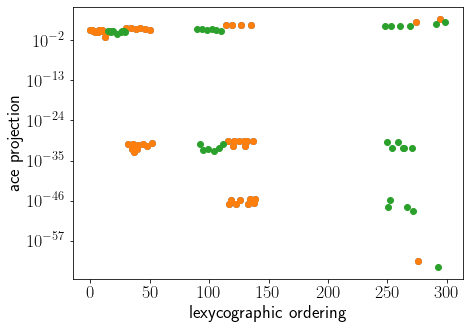

In [41]:
fig, ax = plt.subplots()
ax.plot(selection.iloc[0].values, 'o')
ax.plot(selection.iloc[1].values, 'o')
ax.plot(selection.iloc[2].values, 'o')
ax.set_yscale('log')
ax.set_ylabel('ace projection')
ax.set_xlabel('lexycographic ordering')

In [42]:
ACE_file = os.path.join(descriptorslocation, f'{dataset}-ACE-CNAV.pkl')

CNAV_ACE.to_pickle(ACE_file)

# Prepare for prediction

## ACE no zero

In [43]:
components

['Fe', 'Mo']

In [44]:
nozero_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[0])

In [45]:
all_funcspecs = []
for block in nozero_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs.append(spec) for spec in block.funcspecs]
    

In [46]:
all_funcspecs

[BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,1],  ls=[1,1],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,1],  ls=[2,2],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,1],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,2],  ls=[1,1],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,2],  ls=[2,2],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,2],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,3],  ls=[1,1],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,3],  ls=[2,2],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,3],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[2,2],  ls=[1,1],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[2,2],  ls=[2,2],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=

In [47]:
len(all_funcspecs)

258

In [48]:
NOZEROACEFEATURES = AtomsObjects['atoms'].map(nozero_acer.get_ace_projections)
NOZEROACEFEATURES.name = 'light_ace_projections'

In [49]:
expand_NOZEROACEFEATURES = gf.array_expansions(NOZEROACEFEATURES.to_frame(), ['light_ace_projections'])

In [50]:
CNAV_NOZEROACEFEATURES = gf.featurize_dataframe(expand_NOZEROACEFEATURES, CNList)

In [51]:
CNAV_NOZEROACEFEATURES.shape

(292, 774)

In [52]:
CNAV_ACE.shape

(292, 1800)

In [53]:
NOZERO_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOZERO-ACE-CNAV.pkl')

CNAV_NOZEROACEFEATURES.to_pickle(NOZERO_ACE_file)

## NOZERO NOONE ACE

In [54]:
nozero_noone_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[0,1])

In [55]:
all_funcspecs_nozeronoone = []
for block in nozero_noone_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs_nozeronoone.append(spec) for spec in block.funcspecs]
    

In [56]:
nozero_noone_acer.bbasis_configuration

BBasisConfiguration(deltaSplineBins=0.001, funcspecs_blocks=['Fe', 'Mo', 'Fe Mo', 'Mo Fe', ])

In [57]:
NOZERO_NOONE_ACEFEATURES = AtomsObjects['atoms'].map(nozero_noone_acer.get_ace_projections)
NOZERO_NOONE_ACEFEATURES.name = 'light_ace_projections'

In [58]:
expand_NOZERO_NOONE_ACEFEATURES = gf.array_expansions(NOZERO_NOONE_ACEFEATURES.to_frame(), ['light_ace_projections'])

In [59]:
CNAV_NOZERO_NOONE_CEFEATURES = gf.featurize_dataframe(expand_NOZERO_NOONE_ACEFEATURES, CNList)

In [60]:
CNAV_NOZERO_NOONE_CEFEATURES.shape

(292, 372)

In [61]:
CNAV_ACE.shape

(292, 1800)

In [62]:
NOZERO_NOONE_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOZERO_NOONE-ACE-CNAV.pkl')

CNAV_NOZERO_NOONE_CEFEATURES.to_pickle(NOZERO_NOONE_ACE_file)

## NOZERO NOONE NOTWO ACE

In [63]:
nozero_noone_notwo_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[0,1,2])

In [64]:
all_funcspecs_nozeronoonenotwo = []
for block in nozero_noone_notwo_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs_nozeronoonenotwo.append(spec) for spec in block.funcspecs]
    

In [65]:
nozero_noone_notwo_acer.bbasis_configuration

BBasisConfiguration(deltaSplineBins=0.001, funcspecs_blocks=['Fe', 'Mo', 'Fe Mo', 'Mo Fe', ])

In [66]:
NOZERO_NOONE_NOTWO_ACEFEATURES = AtomsObjects['atoms'].map(nozero_noone_notwo_acer.get_ace_projections)
NOZERO_NOONE_NOTWO_ACEFEATURES.name = 'light_ace_projections'

In [67]:
expand_NOZERO_NOONE_NOTWO_ACEFEATURES = gf.array_expansions(NOZERO_NOONE_NOTWO_ACEFEATURES.to_frame(), ['light_ace_projections'])

In [68]:
CNAV_NOZERO_NOONE_NOTWO_CEFEATURES = gf.featurize_dataframe(expand_NOZERO_NOONE_NOTWO_ACEFEATURES, CNList)

In [69]:
CNAV_NOZERO_NOONE_NOTWO_CEFEATURES.shape

(292, 126)

In [70]:
CNAV_ACE.shape

(292, 1800)

In [71]:
NOZERO_NOONE_NOTWO_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOZERO_NOONE_NOTWO-ACE-CNAV.pkl')

CNAV_NOZERO_NOONE_CEFEATURES.to_pickle(NOZERO_NOONE_NOTWO_ACE_file)

## NOTHREE ACE

In [72]:
nothree_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[3])

In [73]:
all_funcspecs_nothree = []
for block in nothree_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs_nothree.append(spec) for spec in block.funcspecs]
    

In [74]:
NOTHREE_ACEFEATURES = AtomsObjects['atoms'].map(nothree_acer.get_ace_projections)
NOTHREE_ACEFEATURES.name = 'light_ace_projections'

In [75]:
expand_NOTHREE_ACEFEATURES = gf.array_expansions(NOTHREE_ACEFEATURES.to_frame(), ['light_ace_projections'])

In [76]:
CNAV_NOTHREE_ACEFEATURES = gf.featurize_dataframe(expand_NOTHREE_ACEFEATURES, CNList)

In [77]:
CNAV_NOTHREE_ACEFEATURES.shape

(292, 1674)

In [78]:
NOTHREE_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOTHREE-ACE-CNAV.pkl')

CNAV_NOTHREE_ACEFEATURES.to_pickle(NOTHREE_ACE_file)

## NOTHREE NOTWO ACE

In [79]:
nothree_notwo_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[2,3])

In [80]:
all_funcspecs_nothree_notwo = []
for block in nothree_notwo_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs_nothree_notwo.append(spec) for spec in block.funcspecs]

In [81]:
NOTHREE_NOTWO_ACEFEATURES = AtomsObjects['atoms'].map(nothree_notwo_acer.get_ace_projections)
NOTHREE_NOTWO_ACEFEATURES.name = 'light_ace_projections'

In [82]:
expand_NOTHREE_NOTWO_ACEFEATURES = gf.array_expansions(NOTHREE_NOTWO_ACEFEATURES.to_frame(), ['light_ace_projections'])

In [83]:
CNAV_NOTHREE_NOTWO_ACEFEATURES = gf.featurize_dataframe(expand_NOTHREE_NOTWO_ACEFEATURES, CNList)

In [84]:
NOTHREE_NOTWO_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOTHREE_NOTWO-ACE-CNAV.pkl')

CNAV_NOTHREE_NOTWO_ACEFEATURES.to_pickle(NOTHREE_NOTWO_ACE_file)

## NOTHREE NOTWO NOONE ACE

In [85]:
nothree_notwo_noone_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[1,2,3])

In [86]:
all_funcspecs_nothree_notwo_noone = []
for block in nothree_notwo_noone_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs_nothree_notwo_noone.append(spec) for spec in block.funcspecs]

In [87]:
NOTHREE_NOTWO_NOONE_ACEFEATURES = AtomsObjects['atoms'].map(nothree_notwo_noone_acer.get_ace_projections)
NOTHREE_NOTWO_NOONE_ACEFEATURES.name = 'light_ace_projections'

In [88]:
expand_NOTHREE_NOTWO_NOONE_ACEFEATURES = gf.array_expansions(NOTHREE_NOTWO_NOONE_ACEFEATURES.to_frame(), ['light_ace_projections'])

In [89]:
CNAV_NOTHREE_NOTWO_NOONE_ACEFEATURES = gf.featurize_dataframe(expand_NOTHREE_NOTWO_NOONE_ACEFEATURES, CNList)

In [90]:
CNAV_NOTHREE_NOTWO_NOONE_ACEFEATURES.shape

(292, 492)

In [91]:
CNAV_ACE.shape

(292, 1800)

In [92]:
NOTHREE_NOTWO_NOONE_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOTHREE_NOTWO_NOONE-ACE-CNAV.pkl')

CNAV_NOTHREE_NOTWO_NOONE_ACEFEATURES.to_pickle(NOTHREE_NOTWO_NOONE_ACE_file)

## Canonical 

In [93]:
CanonicalAceConfig = copy.copy(AceConfig)

In [94]:
CanonicalAceConfig['elements'] = ['W']

In [95]:
CanonicalACEer = MyPyACECalculator(components = CanonicalAceConfig['elements'], multispace_basis_config=CanonicalAceConfig)

In [96]:
canonicalatomsobjects = AtomsObjects['atoms'].map(reset_symbols)

In [97]:
canonicalacedescriptors = canonicalatomsobjects.map(CanonicalACEer.get_ace_projections)
canonicalacedescriptors.name = 'canonical_ace_projections'

In [98]:
expand_canonical_ace = gf.array_expansions(canonicalacedescriptors.to_frame(),['canonical_ace_projections']) 

In [99]:
CNAV_CANONICAL_ACE = gf.featurize_dataframe(expand_canonical_ace, CNList)

In [100]:
CNAV_CANONICAL_ACE

,canonical_ace_projections_0_0,canonical_ace_projections_0_CN12,canonical_ace_projections_0_CN13,canonical_ace_projections_0_CN14,canonical_ace_projections_0_CN15,canonical_ace_projections_0_CN16,canonical_ace_projections_1_0,canonical_ace_projections_1_CN12,canonical_ace_projections_1_CN13,canonical_ace_projections_1_CN14,...,canonical_ace_projections_67_CN13,canonical_ace_projections_67_CN14,canonical_ace_projections_67_CN15,canonical_ace_projections_67_CN16,canonical_ace_projections_68_0,canonical_ace_projections_68_CN12,canonical_ace_projections_68_CN13,canonical_ace_projections_68_CN14,canonical_ace_projections_68_CN15,canonical_ace_projections_68_CN16
Fe_pv4Mo_sv20.C36-ABBBB.FM,4.197044,2.794807,0.0,0.000000,0.000000,1.402237,4.250290,2.773875,0.0,0.000000,...,0.0,0.000000e+00,0.000000e+00,4.741674e-08,1302.364433,863.234838,0.0,0.000000,0.000000,439.129594
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4.351257,2.217324,0.0,0.983367,0.495760,0.654808,4.377278,2.178551,0.0,1.003156,...,0.0,4.266128e-06,2.691234e-06,4.437061e-07,1560.404537,796.203833,0.0,349.957029,182.328418,231.915256
Fe_pv2Mo_sv11.mu-BBABB.FM,4.187475,2.270445,0.0,0.630194,0.619778,0.667059,4.226473,2.203496,0.0,0.663000,...,0.0,7.721195e-04,4.582254e-13,1.922932e-08,1294.956755,718.523549,0.0,177.428414,163.242359,235.762433
Fe_pv8Mo_sv22.sigma-BBBAB.NM,4.328737,1.442123,0.0,2.307938,0.578676,0.000000,4.371367,1.431755,0.0,2.341648,...,0.0,4.450284e-08,2.070303e-09,0.000000e+00,1519.899615,505.241933,0.0,809.341722,205.315960,0.000000
Fe_pv2Mo_sv11.mu-BBBBA.NM,4.187475,2.270445,0.0,0.630194,0.619778,0.667059,4.226473,2.203496,0.0,0.663000,...,0.0,7.721195e-04,4.582254e-13,1.922932e-08,1294.956755,718.523549,0.0,177.428414,163.242359,235.762433
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6.C15.FM,5.557654,3.706728,0.0,0.000000,0.000000,1.850925,5.295891,3.544942,0.0,0.000000,...,0.0,0.000000e+00,0.000000e+00,3.002058e-62,5302.296910,3542.633437,0.0,0.000000,0.000000,1759.663473
Mo_sv1.bcc.NM,4.000309,0.000000,0.0,4.000309,0.000000,0.000000,4.134325,0.000000,0.0,4.134325,...,0.0,7.612672e-65,0.000000e+00,0.000000e+00,1024.395173,0.000000,0.0,1024.395173,0.000000,0.000000
Mo_sv8.A15.NM,3.996108,0.999231,0.0,2.996877,0.000000,0.000000,4.114518,1.029678,0.0,3.084840,...,0.0,4.481275e-62,0.000000e+00,0.000000e+00,1019.029396,255.017284,0.0,764.012112,0.000000,0.000000
Mo_sv1.fcc.NM,3.993777,3.993777,0.0,0.000000,0.000000,0.000000,4.105636,4.105636,0.0,0.000000,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1016.059238,1016.059238,0.0,0.000000,0.000000,0.000000


In [101]:
canonical_ACE_file = os.path.join(descriptorslocation, f'{dataset}-canonical-ACE-CNAV.pkl')

In [102]:
CNAV_CANONICAL_ACE.to_pickle(canonical_ACE_file)

# I think all the following happened in a conversation with Yuri:

``` python
new_multispace_config = copy.deepcopy(Test.default_multispace_config)
new_multispace_config['embeddings'] = {                                                                                  
     'Cr': {
         'npot': 'FinnisSinclairShiftedScaled',
         'fs_parameters': [1, 1], ## non-linear embedding function: 1*rho_1^1 + 1*rho_2^0.5
         'ndensity': 1,
         'rho_core_cut': 2000,
         'drho_core_cut': 250
         }, 

     'Co': {
         'npot': 'FinnisSinclairShiftedScaled', ## linear embedding function: 1*rho_1^1
         'fs_parameters': [1, 1],
         'ndensity': 1,
         'rho_core_cut': 3000,
         'drho_core_cut': 150
         }, 
    'W': {
         'npot': 'FinnisSinclairShiftedScaled', ## linear embedding function: 1*rho_1^1
         'fs_parameters': [1, 1],
         'ndensity': 1,
         'rho_core_cut': 3000,
         'drho_core_cut': 150
         }
     }
new_multispace_config['functions'] = {
                     'UNARY':  {
                             'nradmax_by_orders': [5, 1, 1, 1, 1],
                             'lmax_by_orders': [ 0, 3, 2,1,0],
                             },
#                      'Mo':  {
#                              'nradmax_by_orders': [5, 1, 1, 1, 1],
#                              'lmax_by_orders': [ 0, 3, 2,1,0],
#                              },
                     'BINARY':  {
                             'nradmax_by_orders': [5, 1, 1, 1, 1],
                             'lmax_by_orders': [ 0, 3, 2,1,0],
                             }
    }

# new_multispace_config['functions'] = {
#                      'ALL':  {
#                              'nradmax_by_orders': [5, 1, 1, 1, 1],
#                              'lmax_by_orders': [ 0, 3, 2,1,0],
#                              }
#     }

bas= construct_bbasisconfiguration(new_multispace_config)

bas.funcspecs_blocks[2].funcspecs

bas.funcspecs_blocks[2].funcspecs

construct_bbasisconfiguration??

Test.default_multispace_config

construct_bbasisconfiguration(Test.default_multispace_config)



ShorterFunctionsOptions = copy.deepcopy(default_options)

ShorterFunctionsOptions['functions'] = new_functions

ShorterFunctionsACE = MyPyACECalculator(components=['Fe','Mo'], multispace_basis_config=ShorterFunctionsOptions)

ACEFEATURES_shorter_functions = AtomsObjects['atoms'].map(ShorterFunctionsACE.get_ace_projections)
ACEFEATURES.name = 'ace_projections_shorter_functions'
```